# 01 — Traffic Analysis & Trace Validation
**FlashBalanceAI | Phase 2 — Dataset & Traffic Generation**

**Purpose:** Explore and validate the synthetic flash-sale traffic generator across all evaluation scenarios (E1–E4, E6, E9) and verify alignment with Alibaba Cloud cluster trace patterns.

**Key Specifications:**
- Episode Length: 7,900 steps @ 100 ms resolution ≈ 13.17 minutes
- Baseline Traffic: ~100 req/s
- Flash-Sale Bursts: 10× (1,000 req/s), 50× (5,000 req/s), 100× (10,000 req/s)
- Burst Profiles: Exponential onset (E2–E4), Gaussian noise injection (E6, 40%), Triangular transfer (E9)

**Author:** Agrima Gupta (24BIT0253) | Owner/Role: Phase 7 Results

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# Set project root
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / 'src').exists() else cwd.parent
if str((project_root / 'src').resolve()) not in sys.path:
    sys.path.insert(0, str((project_root / 'src').resolve()))

from traffic.traffic_generator import TrafficGenerator

sns.set_theme(style='whitegrid', font_scale=1.1)
print(f'Project root successfully resolved: {project_root}')

Project root successfully resolved: C:\Users\Devkanti Sarkar\Desktop\DRL_Cloud_Load_Balancing_Cloud_Project_2026


## 1. Load Traffic Scenario Configuration
Reads parameters from `configs/traffic_config.yaml`.

In [2]:
config_path = project_root / 'configs' / 'traffic_config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    traffic_cfg = yaml.safe_load(f)

scenarios = traffic_cfg['scenarios']
print(f'Loaded {len(scenarios)} traffic scenarios from {config_path.name}:')
for s_name, s_params in scenarios.items():
    mult = s_params.get('burst_multiplier', 1)
    noise = s_params.get('noise_std_fraction', 0.0) * 100
    print(f'  - {s_name:<16}: burst={mult:>3}x, noise={noise:>2.0f}%, shape={s_params.get("burst_profile", "exponential")}')

Loaded 9 traffic scenarios from traffic_config.yaml:
  - e1_baseline     : burst=1.0x, noise= 5%, shape=exponential
  - e2_10x          : burst=10.0x, noise=10%, shape=exponential
  - e3_50x          : burst=50.0x, noise=10%, shape=exponential
  - e4_100x         : burst=100.0x, noise=10%, shape=exponential
  - e6_noisy        : burst=2.0x, noise=40%, shape=exponential
  - train_episodes  : burst=10.0x, noise=10%, shape=exponential
  - val_episodes    : burst=10.0x, noise=10%, shape=exponential
  - e9_triangular   : burst=10.0x, noise=10%, shape=exponential
  - e9_transfer     : burst=10.0x, noise=10%, shape=exponential


## 2. Generate and Analyze Traffic Profiles (E1–E4, E6, E9)
Generates discrete-time arrival rate series for each scenario and verifies temporal metrics.

In [3]:
profiles = {}
stats_records = []
output_dir = project_root / 'experiments' / 'results' / 'traffic_profiles'
output_dir.mkdir(parents=True, exist_ok=True)

scenario_keys = ['e1_baseline', 'e2_10x', 'e3_50x', 'e4_100x', 'e6_noisy', 'e9_transfer']
for name in scenario_keys:
    gen = TrafficGenerator.from_config(name)
    gen.seed = 42
    series = gen.generate()
    profiles[name] = series
    base_rate = float(series[0])
    peak_rate = float(np.max(series))
    stats_records.append({
        'Scenario': name,
        'Steps': len(series),
        'Duration (min)': f'{len(series) * 0.1 / 60.0:.2f}',
        'Baseline (req/s)': f'{base_rate:.1f}',
        'Peak (req/s)': f'{peak_rate:.1f}',
        'Multiplier': f'{peak_rate / base_rate:.1f}x',
        'Mean (req/s)': f'{float(np.mean(series)):.1f}',
        'Std (req/s)': f'{float(np.std(series)):.1f}',
    })

df_stats = pd.DataFrame(stats_records)
print(df_stats.to_string(index=False))
assert all(len(s) == 7900 for s in profiles.values()), 'Episode length must be 7900 steps.'

   Scenario  Steps Duration (min) Baseline (req/s) Peak (req/s) Multiplier Mean (req/s) Std (req/s)
e1_baseline   7900          13.17            101.5        343.7       3.4x        116.3        54.3
     e2_10x   7900          13.17            103.0       1345.4      13.1x        597.4       372.1
     e3_50x   7900          13.17            103.0       6727.0      65.3x       2474.2      2203.4
    e4_100x   7900          13.17            103.0      13454.0     130.6x       4746.3      4526.0
   e6_noisy   7900          13.17            112.2        649.7       5.8x        181.8        89.2
e9_transfer   7900          13.17            103.0       1321.6      12.8x        441.8       301.8


## 3. Multi-Scenario Traffic Comparison Plot
Displays the arrival rate curves over the entire 13.17-minute episode.

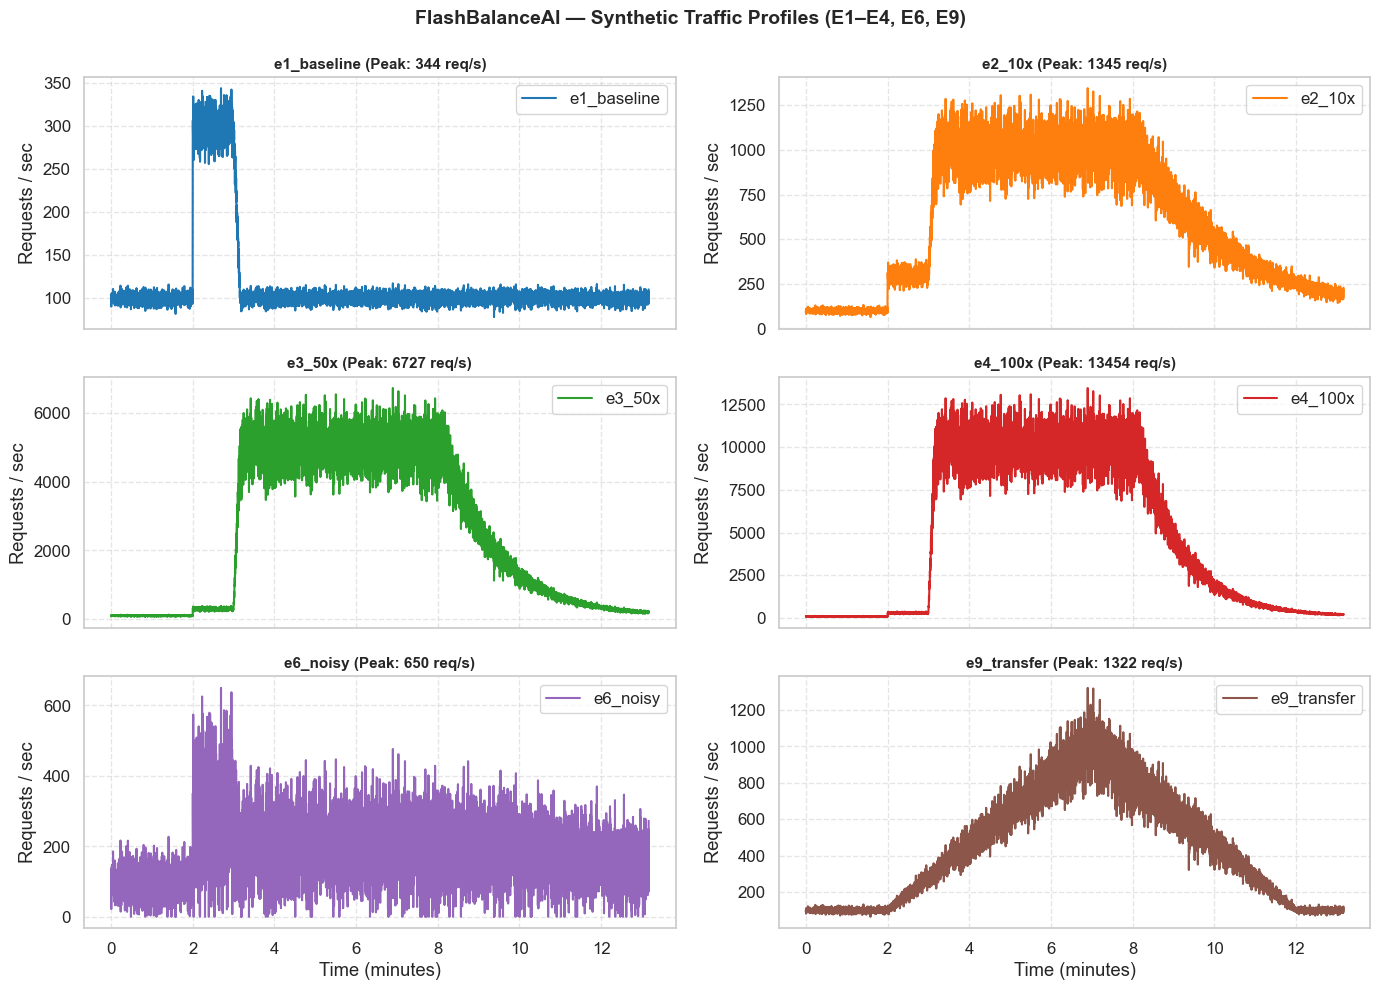

Saved profile figure to: C:\Users\Devkanti Sarkar\Desktop\DRL_Cloud_Load_Balancing_Cloud_Project_2026\experiments\results\traffic_profiles\all_scenarios_comparison.png


In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()
colors = sns.color_palette('tab10', len(scenario_keys))
time_minutes = np.arange(7900) * 0.1 / 60.0

for idx, name in enumerate(scenario_keys):
    ax = axes[idx]
    series = profiles[name]
    ax.plot(time_minutes, series, color=colors[idx], linewidth=1.5, label=name)
    ax.set_title(f'{name} (Peak: {np.max(series):.0f} req/s)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Requests / sec')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')
    if idx >= 4:
        ax.set_xlabel('Time (minutes)')

plt.suptitle('FlashBalanceAI — Synthetic Traffic Profiles (E1–E4, E6, E9)', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
fig_path = output_dir / 'all_scenarios_comparison.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved profile figure to: {fig_path}')

## 4. Flash-Sale Spike Window Onset Dynamics
Detailed inspection of the surge onset period (100 s to 300 s).

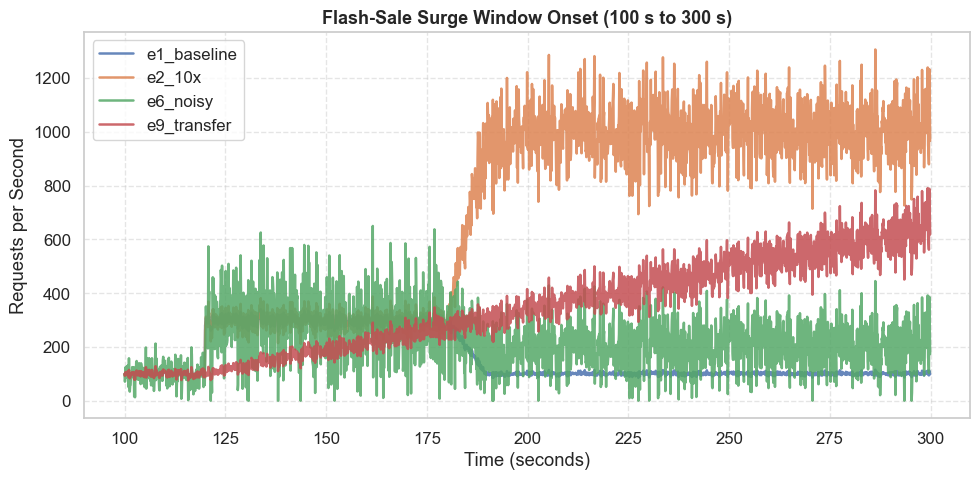

Saved surge onset figure to: C:\Users\Devkanti Sarkar\Desktop\DRL_Cloud_Load_Balancing_Cloud_Project_2026\experiments\results\traffic_profiles\spike_onset_zoom.png


In [5]:
plt.figure(figsize=(10, 5))
zoom_slice = slice(1000, 3000)
time_zoom = np.arange(1000, 3000) * 0.1

for name in ['e1_baseline', 'e2_10x', 'e6_noisy', 'e9_transfer']:
    plt.plot(time_zoom, profiles[name][zoom_slice], label=name, alpha=0.85, linewidth=1.8)

plt.title('Flash-Sale Surge Window Onset (100 s to 300 s)', fontsize=13, fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Requests per Second')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
spike_path = output_dir / 'spike_onset_zoom.png'
plt.savefig(spike_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved surge onset figure to: {spike_path}')